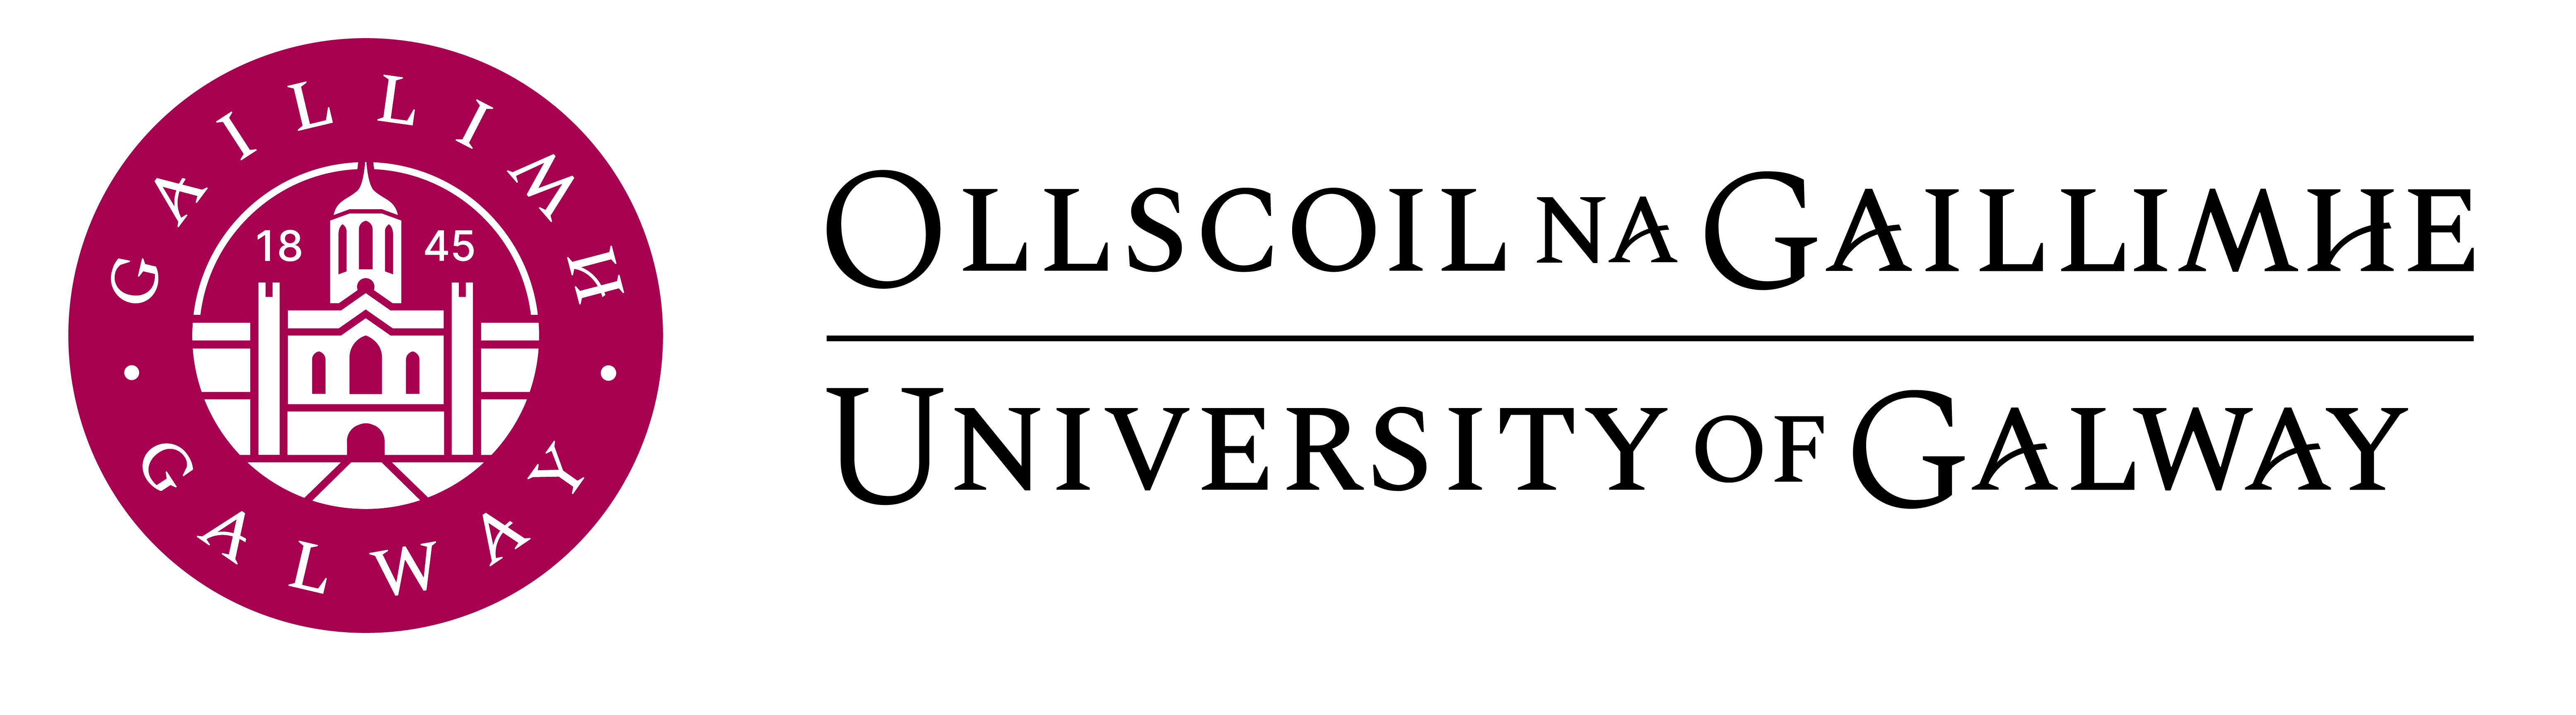

# ***CT5120 Assignment 1*** (Total 100 marks)

> ⚠️ <font color="red">**Disclaimer:** This assignment contains examples of hate speech and offensive content, included strictly for academic purposes. </font>

---
# **Task**

This task is focused on **Hate Speech Detection** and **Rationale Extraction** from social media comments.  
Please complete this task and **upload your answers to Canvas as an iPython Notebook ONLY with saved outputs**.  

📅 ***Deadline:*** **23:59** on **October 27th, 2025**  (Ireland Time)

⚠️ ***Late submissions*** will be penalised by **1% per day (for one week until November 03, 2025)**. Submission after these deadlines will not be considered.


👤 This is an ***individual assignment*** and your work must be your own.  

**<font color="red">Strictly no Generative AI</font> : Do the assignment by yourself, write codes and answers fully in your own words without using AI tools.**  

<font color="red">**Note:** You must disable the AI features on Google Colab before working on this assignment.  
  
You can follow this video guide: [How to disable AI in Colab](https://youtu.be/qrGZv8nPh1o)</font>  


You may use libraries such as **Scikit-Learn** to complete this assignment.

⚠️ **Important:**  
- Make sure you fill in your **Name** and **Student ID** by running the below cell.  
- Do **not** modify any other cells in this notebook except those explicitly marked with  
  **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`**.  
- Ensure that all cells run successfully before submission.  
- We recommend using **Google Colab** to avoid any dependency issues.  



---
**Student Details**

In [1]:
# Enter your details below
NAME = input("Student Name   : ")
STUDENT_ID = input("Student ID     : ")

print(f"Student Name   : {NAME}")
print(f"Student ID     : {STUDENT_ID}")


Student Name   : Karthik Subramanya Ballal
Student ID     : 25242055


---

## **Summary**

In this task, given a tweet (text), you have two objectives:

1. **Hate Speech Detection** – Classify the tweet into one of three classes:  
   - **Hateful**  
   - **Offensive**  
   - **Normal**

2. **Hate Rationale Extraction** – Extract the sequence of words from the tweet that expresses the hate.

---

### **Example (from the train dataset)**
<!-- <p align="center">
  <img src="https://drive.google.com/uc?id=1tqMOBR7YJufemSmsArlFBRbgbKxgrK2_" alt="Second Image" width="700"/>
</p> -->

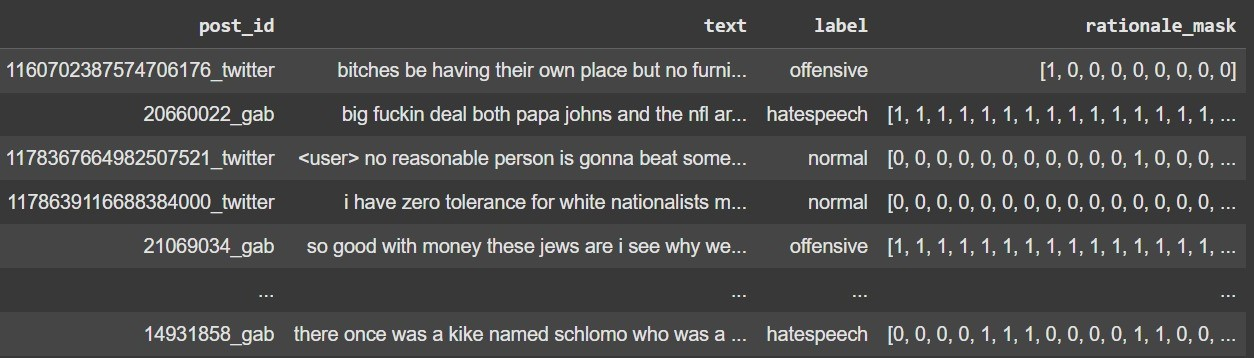

### 📑 Dataset Columns

1. **`post_id`** – Unique ID of the post (with platform name).  
2. **`text`** – The raw text content of the social media post (what users wrote).  
3. **`label`** – The category of the post:  
   - **normal** → harmless text  
   - **offensive** → rude/insulting text  
   - **hatespeech** → hateful text targeting groups/people  
4. **`rationale_mask`** – Highlights important words in the text  
   - `1` = important word (evidence for hate/offense)  
   - `0` = not important  


---
# **Dataset Details**

The dataset is divided into **three parts**: **Training**, **Development (Dev)**, and **Test** sets.  

1. **Training set**  
   - Used to **train your model** (learn patterns from the data).  
   - This is the largest portion of the dataset.  

2. **Development (Dev) set**  
   - A small part of the training data that is **held out**.  
   - Used to **validate your model** while training and for **hyperparameter tuning**.  
   - Helps avoid overfitting (your model performing well on training but poorly on unseen data).  

3. **Test set**  
   - Contains **unlabeled data** (labels are hidden).  (*HERE*: in this assignment we provided labeled dataset)
   - Used only for **final evaluation** of your model.  
   - You will generate a **prediction file** for this set and submit it.  

---

# **Installing packages**

In [2]:
# Use this cell for installing the packages by uncommenting below only if you are running this notobook locally.


!pip install pandas
!pip install matplotlib
!pip install -U scikit-learn
!pip install seaborn
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\KARTHIK BALLAL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\KARTHIK BALLAL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\KARTHIK BALLAL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\KARTHIK BALLAL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\KARTHIK BALLAL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# **Importing Libraries & Dataset files**

In [3]:
import re
import inspect
import requests
import pandas as pd
import numpy as np
import seaborn as sns
from io import StringIO
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from sklearn.ensemble import AdaBoostClassifier

In [4]:
# Load the dataset

def download_file_from_google_drive(file_id):
    """
    Downloads a CSV file from Google Drive using its file_id
    and returns the content as text.
    """
    URL = "https://drive.google.com/uc?export=download&id=" + file_id
    response = requests.get(URL)
    response.raise_for_status()
    return response.text

# Replace FILE_ID with the actual IDs from your links
file_id_train = "1w24oujFndvBuj72FBtleW31J3XJniiXM"
file_id_dev   = "1ef1MoM2BSliECG29-a3Scxvyw7DNww1e"
file_id_test  = "16mcf7T428qlFIdE4NeKptbY9vtir2V2f"

# Read CSVs directly into pandas
df_train = pd.read_csv(StringIO(download_file_from_google_drive(file_id_train)))
df_dev   = pd.read_csv(StringIO(download_file_from_google_drive(file_id_dev)))
df_test  = pd.read_csv(StringIO(download_file_from_google_drive(file_id_test)))

# df_train = pd.read_csv('./data_assignment1/train.csv')
# df_dev  = pd.read_csv('./data_assignment1/dev.csv')
# df_test  = pd.read_csv('./data_assignment1/test.csv')

# Print dataset shapes
print("Train shape:", df_train.shape)
print("Dev shape:", df_dev.shape)
print("Test shape:", df_test.shape)


Train shape: (3224, 4)
Dev shape: (806, 4)
Test shape: (1008, 4)


# **1. Exploratory Data Analysis (EDA) (Total = 20 marks)**

## **Task 1a: Class distribution (5 marks)**

---

*Note*: The output of the code should look like this (color doesn't matter).
<!-- <p style="margin-left:200px;">
  <img src="https://drive.google.com/uc?id=15dsJTaL1DDzwXk3sk3N2rTBNp3h5AZZx" alt="Inserted Image" width="600"/>
</p> -->

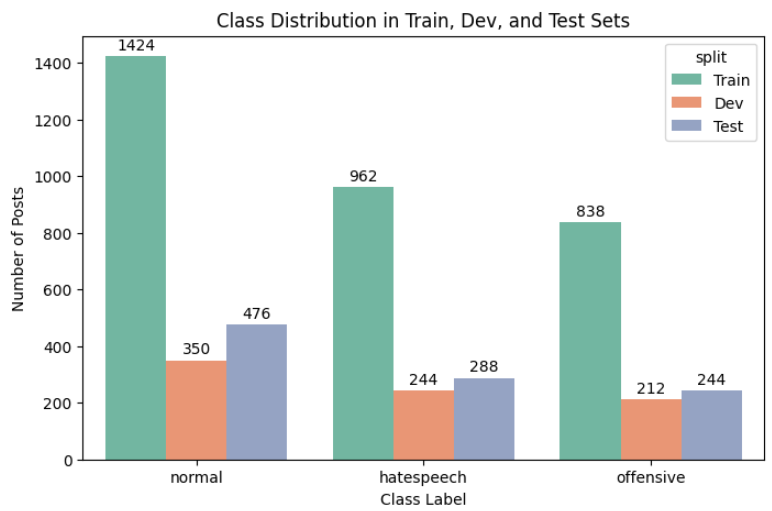


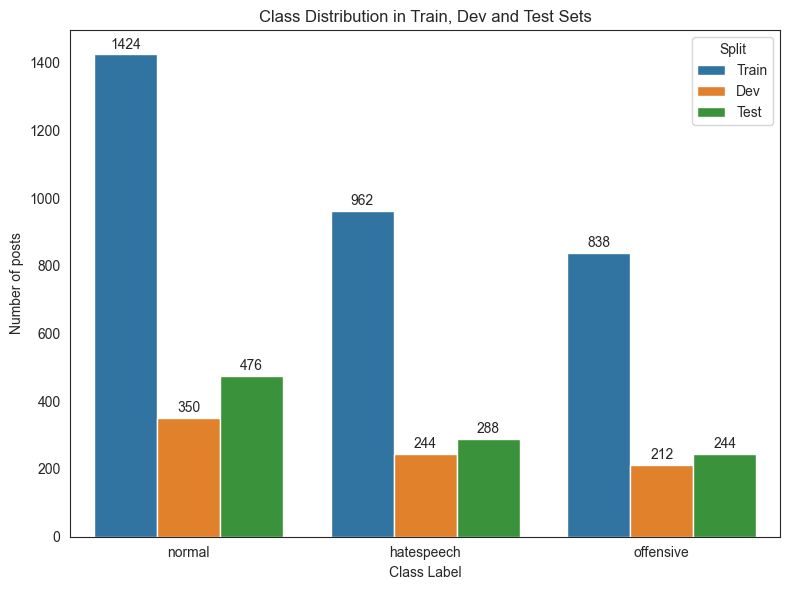

In [5]:
def plot_class_distribution(df_train, df_dev, df_test):
    """
    TODO:
    - Count the number of posts for each label in Train, Dev, and Test sets
    - Combine the counts into one dataframe
    - Plot a bar chart comparing the distributions across splits
    - Add counts on top of each bar for clarity
    """
    # YOUR CODE HERE
    # Count of Train, Dev and Test is stored in the following variables: [value_counts gives count by labels resp.]
    train_counts = df_train['label'].value_counts()
    dev_counts = df_dev['label'].value_counts()
    test_counts = df_test['label'].value_counts()

    #Created a combined data frame that has labels and itd count values, 
    df = pd.DataFrame({
        'Label': list(train_counts.index) * 3, #train_counts.index gives the labels, this is multiplied by 3 for each dataset
        'Dataset': ['Train'] * 3 + ['Dev'] * 3 + ['Test'] * 3, #Multiplied by 3 for each dataset to match with each label
        'Count': train_counts.tolist() + dev_counts.tolist() + test_counts.tolist() #As value_counts gave count wrt labels 
    })

    #Plotted Image size and seaborn for bar plot
    plt.figure(figsize=(8,6))
    sns.set_style('white')
    graph = sns.barplot(data=df, x='Label', y='Count', hue='Dataset')

    #These are containers that containes objects which have all the information of the list of all bar groups
    for c in graph.containers:
        graph.bar_label(c, fmt='%d', padding=2)

    #Some key information to be shown on the graph
    graph.set_title("Class Distribution in Train, Dev and Test Sets")
    graph.set_xlabel("Class Label")
    graph.set_ylabel("Number of posts")
    graph.legend(title='Split')
    plt.tight_layout()
    plt.show()

    # raise NotImplementedError() # comment this line one you entered your code

# Call the function
plot_class_distribution(df_train, df_dev, df_test)

## **Task 1b: Rationale analysis (Total 10 marks)**

**1. Span length charts:** (5 marks)


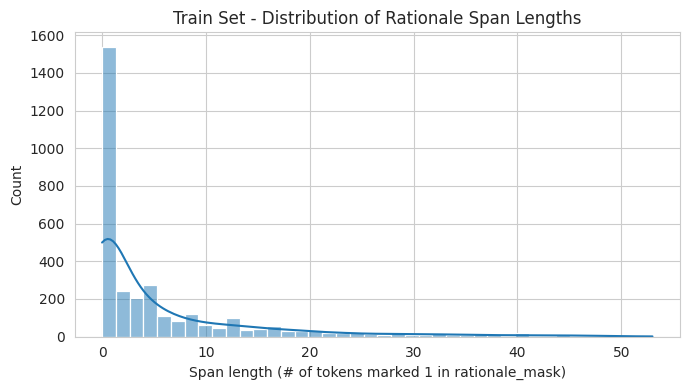

**2. Rationale Coverage Ratio:** (5 marks)

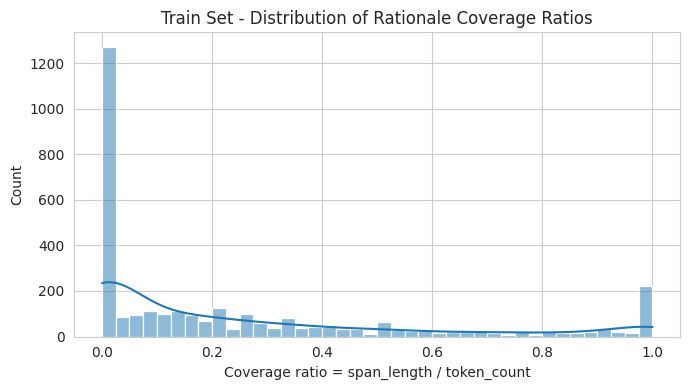

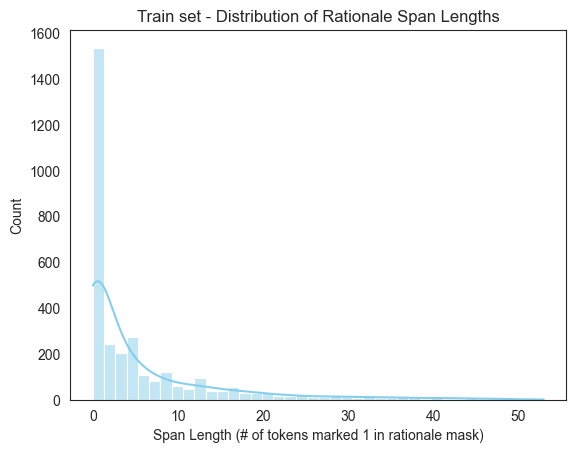

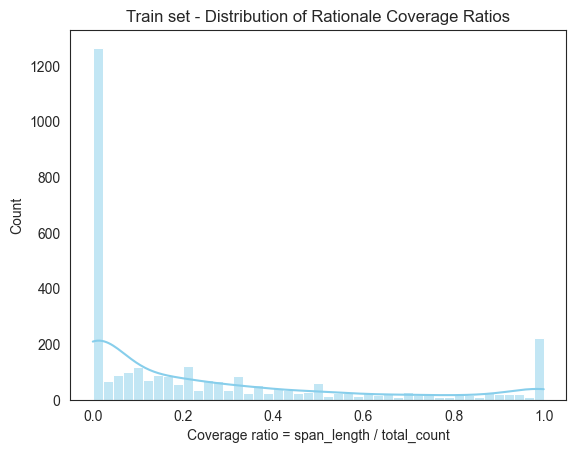

In [6]:
rationale_mask = []
def analyze_span_and_tokens(df):
    """
    TODO:
    - Plot a bar chat for distribution of rationale span length - (5 marks)
    - Plot a bar chat for distribution of rationale coverage ratios - (5 marks)
    """
    # YOUR CODE HERE
    span_vector = []
    ratio_vector = []

    for rm in df_train['rationale_mask']:
        r_mask = [int(x) for x in rm.strip("[]").split(",")]
        rationale_mask.append(r_mask)
        span_vector.append(r_mask.count(1))
        ratio_vector.append(r_mask.count(1)/(len(r_mask)))

    # print(len([i for i in span_vector if i == 1]))

    sns.histplot(span_vector, bins=40, kde=True, color="skyblue")
    plt.xlabel('Span Length (# of tokens marked 1 in rationale mask)')
    plt.ylabel('Count')
    plt.title('Train set - Distribution of Rationale Span Lengths')
    plt.show()

    sns.histplot(ratio_vector, bins=45, kde=True, color="skyblue")
    plt.xlabel('Coverage ratio = span_length / total_count')
    plt.ylabel('Count')
    plt.title('Train set - Distribution of Rationale Coverage Ratios')
    plt.show()
    # raise NotImplementedError() # comment this line one you entered your code

# Call the function
# For train set
train = analyze_span_and_tokens(df_train)

## **Task 1c: Explanation (5 marks)**

**Question:** Explain the Exploratory Data Analysis (EDA) process carried out in *Task 1a* and *Task 1b*





Your explanation should be written in your own words `(strictly no use of Generative AI)` and should not exceed **100 words** in length.

```
# YOUR ANSWER HERE



```

# **2. Hate Speech Detection (Total = 40 marks)**

**Task:** Train a sequence classification model. The model should take the text as input and return 1 out of 3 as hate speech label.

**Label**: Hateful, Offensive, Normal

`INPUT : (text)`

`OUTPUT: Hate_label (i.e. one class from (Hateful, Offensive, Normal))`

Using the data provided in the Training and Development sets, extract feature vectors by applying the TF-IDF encoding technique. Ensure that the number of features in the TF-IDF encoded data is fixed at 1024.

## **Task 2a: Feature extraction (5 marks)**
In this task, you are required to extract numerical features from the text data using **TF-IDF (Term Frequency-Inverse Document Frequency)**.  

- Use `TfidfVectorizer` from `sklearn` to convert the text into feature vectors for training, validation, and test sets.
- Return the feature matrices (`X_train`, `X_dev`, `X_test`) along with their corresponding labels (`y_train`, `y_dev`, `y_test`).  




In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


def extract_features(df_train, df_dev, df_test):
    """This function takes the dataframes for training, tesing and validation and
        returns encoded features and the labels required to train the models

        train_x = [training TFIDF features]
        dev_x = [validation TFIDF features]
        test_x = [test TFIDF features]

        train_y = [lab_1, lab_2 , ..., lab_n]
        dev_y = [lab_1, lab_2 , ..., lab_n]
        test_y = [lab_1, lab_2 , ..., lab_n]
    """

    # YOUR CODE HERE


    raise NotImplementedError()  # comment this line one you entered your code


In [ ]:
(train_x, train_y), (dev_x, dev_y), (test_x, test_y) = extract_features(df_train, df_dev, df_test)

In [ ]:
assert train_x.shape[0] == df_train.shape[0]
assert dev_x.shape[0] == df_dev.shape[0]
assert test_x.shape[0] == df_test.shape[0]

## **Task 2b: Support Vector Machines (SVM) (10 marks)**

In this task, you are required to train and validate a classifier using the TF-IDF features from the previous step.  

- Implement the `get_model` function to build and train a Support Vector Machine (SVM) model.  
- Train the model using the training data (`train_x`, `train_y`).  
- Use the development set (`dev_x`, `dev_y`) to validate the model and report its performance.  
- Ensure that the returned model is correctly initialized, trained, and ready for testing.  


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def get_model(train_x, train_y, dev_x, dev_y):
    """
    Build and train an SVM classifier using training data.
    Validate the model on the development set.
    print("Development Accuracy:", accuracy_score(dev_y, dev_pred))
    Return the trained model.
    """
    # YOUR CODE HERE



    raise NotImplementedError()   # comment this line one you entered your code

In [ ]:
# call the function
model = get_model(train_x, train_y, dev_x, dev_y)

In [ ]:
model_type = str(type(model))
assert 'sklearn' in model_type
assert 'svm' in model_type

## **Task 2c: Predictions and Evaluation (5 marks)**

In this task, you will use the trained model to make predictions on unseen test data and evaluate its performance.  

- Implement the `make_predictions_on_test` function to generate predictions for the test set.  
- Implement the `calc_pre_recall_f1` function to calculate **precision**, **recall**, and **F1-score** using the predicted and true labels.  
- Report the evaluation results to assess the performance of your model.  


In [ ]:
def make_predictions_on_test(test_x, model):

    # YOUR CODE HERE

    raise NotImplementedError()   # comment this line one you entered your code

In [ ]:
pred_y = make_predictions_on_test(test_x, model)

In [ ]:
assert len(pred_y) == test_y.shape[0]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calc_pre_recall_f1(pred_y, test_y):

    # YOUR CODE HERE

    raise NotImplementedError()   # comment this line one you entered your code

In [ ]:
prec_mac_svm, rec_mac_svm, f1_mac_svm = calc_pre_recall_f1(pred_y, test_y)

In [ ]:
assert prec_mac_svm <= 1.0
assert prec_mac_svm > 0.0

assert rec_mac_svm <= 1.0
assert rec_mac_svm > 0.0

assert f1_mac_svm <= 1.0
assert f1_mac_svm > 0.0
# DO NOT DELETE !!!

<!-- ## **Task 2d: Explanation (10 marks)**

Provide a detailed explanation of the implementation process for feature extraction using TF-IDF and the Support Vector Machine (SVM) model, including how predictions are generated. -->

## **Task 2d: Explanation (10 marks)**

Provide a detailed explanation of your implementation for this task.  

- Describe the process of **feature extraction** using TF-IDF and why it is suitable for text classification.  
- Explain how the **Support Vector Machine (SVM)** model was trained and validated using the training and development sets.  
- Discuss how predictions were generated on the test set.  
- Comment on the evaluation metrics (precision, recall, F1-score) and what they reveal about your model's performance.  


Your explanation should be written in your own words `(strictly no use of Generative AI)` and should not exceed **150 words** in length.

```
# YOUR ANSWER HERE


```



## **Task 2e: Improving the prediction (5 marks)**

In this task, you will experiment with improving the prediction performance of your model.  

- Implement the `improved_predictions` function to train a classifier using the training data (`train_x`, `train_y`).  
- Use the development set (`dev_x`, `dev_y`) to guide improvements, such as parameter tuning, trying alternative feature extraction methods, or alternative classifier.  
- Once the model is trained and validated, use it to generate predictions on the test set (`test_x`).  
- Return the predicted labels and ensure they match the size of the test set.  


In [ ]:
def improved_predictions(train_x, train_y, dev_x, dev_y, test_x):
    """
    Train an improved classifier using train_x, train_y and validate on dev_x and dev_y.
    Apply improvements (e.g., parameter tuning, feature extraction methods, alternative models).
    Use the final model to generate predictions on the test_x.
    """
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
y_pred_improved = improved_predictions(train_x, train_y, dev_x, dev_y, test_x)
assert len(y_pred_improved) == test_y.shape[0]
assert all([y in set(test_y) for y in set(y_pred_improved)])

In [ ]:
prec_mac_improv, rec_mac_improv, f1_mac_improv = calc_pre_recall_f1(y_pred_improved, test_y)
# DO NOT DELETE THIS CELL !!!

## **Task 2f: Explanation (5 marks)**

Provide a concise explanation of the approach you used in Task 2e to improve prediction performance.  

Your explanation should:  
- Clearly state the specific change or improvement you applied.  
- Explain why you chose this approach and how it addresses limitations of the previous approach.  

Your explanation should be written in your own words `(strictly no use of Generative AI)` and should not exceed **100 words** in length.




```
# YOUR ANSWER HERE



```



# **3. Rationale Extraction (Total = 40 marks)**

The goal of this task is to **extract the hate rationale** given the text and its label.  
A hate rationale is the part of the text (a span of words or phrases) that most strongly conveys hate/offensive content, and it is the justification for why the text is labeled as hate speech or offensive.  

**Input**: (text, label)  
**Output**: (selected_text / rationale span)  

**Example**  

- **Text**: *"<user> i really fucking hate you right now"*  
- **Label**: *hate*  
- **Extracted Rationale**: *"fucking hate you"*  

You may use any suitable **evaluation metrics** (e.g., accuracy, F1-score, token-level overlap, Jaccard similarity) depending on your approach.  




## **Task 3a: Model Implementation and Improvement (20 marks)**

In this task, you will build a model for rationale identification.  

- **Input**: Training set (`train_df`) and Development set (`dev_df`).  
- **Output**: A trained model, along with the evaluation score on the development set.  
- You are expected to implement a baseline model and then improve it (e.g., through hyperparameter tuning, model selection, or different architectures).  
- Print the evaluation score(s) for the chosen metric(s).  


In [ ]:
def train_rationale_model(train_df, dev_df):
    """
    Train a rationale identification model on the training set
    and evaluate it on the development set.

    Args:
        train_df (pd.DataFrame): Training split with [post_id, text, label, rationale_mask].
        dev_df (pd.DataFrame): Development split with [post_id, text, label, rationale_mask].

    Returns:
        model (object): Trained rationale identification model.
        score (float/dict): Evaluation score(s) on the dev set.
    """
    # YOUR CODE HERE

    raise NotImplementedError()

# Example usage
model, dev_score = train_rationale_model(df_train, df_dev)
print("Development Score:", dev_score)

## **Task 3b: Rationale Detection (5 marks)**

In this task, you will use the trained model to detect rationales on unseen text.  

- **Input**: Test set (`test_df`) and the trained model.  
- **Output**: Predicted rationale spans for each text in the test set.  


In [ ]:
def detect_rationales(model, test_df):
    """
    Use the trained model to predict rationales on the test set.

    Args:
        model (object): Trained rationale identification model.
        test_df (pd.DataFrame): Test split with [text, label].

    Returns:
        predictions (list): Predicted rationale spans for each test example.
    """
    # YOUR CODE HERE

    raise NotImplementedError()

# Example usage
test_rationales = detect_rationales(model, df_test)
assert len(test_rationales) == df_test.shape[0]


## **Task 3c: Evaluation (5 marks)**

In this task, you will evaluate the performance of your rationale extraction system.  

- **Input**: Test set with gold rationales, predicted rationales.  
- **Output**: Evaluation score(s) using your chosen metric(s).  


In [ ]:
def evaluate_rationales(predictions, test_df):
    """
    Evaluate the quality of predicted rationales against gold rationales (rationale_mask).

    Args:
        predictions (list): Predicted rationale spans.
        test_df (pd.DataFrame): Test split with [text, label, rationale_mask].

    Returns:
        score (float/dict): Evaluation score(s) for the rationale extraction task.
    """
    # YOUR CODE HERE

    raise NotImplementedError()

# Example usage
test_score = evaluate_rationales(test_rationales, df_test)
print("Test Score:", test_score)


## **Task 3d: Explanation (10 marks)**

Provide a detailed explanation of your implementation for Tasks 3a, 3b, and 3c.  

- Explain your model design, training process, and improvements applied.
- Explain how your model detects rationales on new/unseen text.
- Explain your evaluation process, including why you chose your metric(s) and what the results show.

Your explanation should be written in your own words, structured clearly, and should not exceed **150 words** in total.  


```
# YOUR ANSWER HERE


```
